# Aprendizaje Automático
#### Primer cuatrimestre 2026

## Introducción

Vamos a volcar un montón de "ingredientes" al principio, algunos pequeños, algunos más grandes. Luego los vamos a ir cocinando y combinando para hacer un plato rico (CoPilot predijo estas oraciones y me gustaron).




### Notación

En general, vamos a (intentar) seguir la notación de *The Elements of Statistical Learning* de Hastie, Tibshirani y Friedman (2009). Esta notación consiste en:

* $N$ suele ser el número de observaciones, y $p$ el número de variables de entrada.
    * A veces $N$ puede aparecer en minúsculas, $n$.

* Una variable de entrada es $X$. Es un vector, sus componentes son $X_j$. 
    * Las mayúsculas suelen referir al aspecto más simbólico o genérico de las variables.

* Una variable de salida cuantitativa es $Y$, y una variable de salida cualitativa es $G$ (para grupo). Las variables de salida cuantitativas son números, y las cualitativas son categorías.
    * $G$ toma valores en el set finito $ \mathcal{G} = \{1, 2, \ldots, K\}$, donde $K$ es el número de categorías o clases.

### Notación

* $x_{i,j}$ es la observación de la variable $j$-ésima en la instancia $i$-ésima. En general, las observaciones se denotan con minúsculas (*variables en mayúscula, observaciones en minúscula*).

#### Matrices

* Una matriz suele representarse en mayúscula y en negrita. En particular, $\textbf{X}$ es una matriz de observaciones de variables de entrada, donde cada fila es una observación y cada columna es una variable. Por ejemplo, si tenemos $N$ observaciones y $p$ variables de entrada, entonces $\textbf{X}$ es una matriz de $N \times p$.

$$ \textbf{X} = \begin{bmatrix} 
x_{1,1} & x_{1,2} & \cdots & x_{1,p} \\
x_{2,1} & x_{2,2} & \cdots & x_{2,p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{N,1} & x_{N,2} & \cdots & x_{N,p}
\end{bmatrix} $$

### Notación

#### Vectores

* En general, los vectores se escriben sin negrita, salvo cuando tienen $N$ componentes. De esta manera, podemos distinguir un vector de $p$ componentes para la instancia $x_i$ de un vector de $N$ componentes para las observaciones $\textbf{x}_j$ de la variable $X_j$. 

Entonces: 

* La columna $j$-esima de $\textbf{X}$ es el vector $\textbf{x}_j$, que contiene todas las observaciones de la variable $j$-ésima. De esta manera, la matriz $\textbf{X}$ puede escribirse como:

$$ \textbf{X} = \begin{bmatrix}
\textbf{x}_1 & \textbf{x}_2 & \cdots & \textbf{x}_p
\end{bmatrix} $$ 

cada uno con $N$ observaciones.

### Notación

#### Vectores

* La fila $i$-ésima de $\textbf{X}$ es una observación de todas las variables de entrada para la instancia $i$. Como **todos los vectores se asumen vectores columna**, la fila $i$-ésima de $\textbf{X}$ se denota como $x_i^T$, que es la transpuesta del vector columna $x_i$. De esta manera, la matriz $\textbf{X}$ puede escribirse como:

$$ \textbf{X} = \begin{bmatrix}
x_1^T \\
x_2^T \\
\vdots \\
x_N^T
\end{bmatrix} $$




In [4]:
import numpy as np

X_train = np.array([1,2,3]).reshape(3,1)
print(X_train.shape)

(3, 1)


In [5]:
X_train

array([[1],
       [2],
       [3]])

In [6]:
from sklearn.preprocessing import StandardScaler

StandardScaler().fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## ¿Cuál es la relación entre el aprendizaje automático y la estadística?

### Aprendizaje no supervisado

Dada un conjunto de datos compuesto de muchas variables $X$ donde, en principio, no quiero predecir ninguna etiqueta en particular.

¿Qué puedo decir sobre $X$?

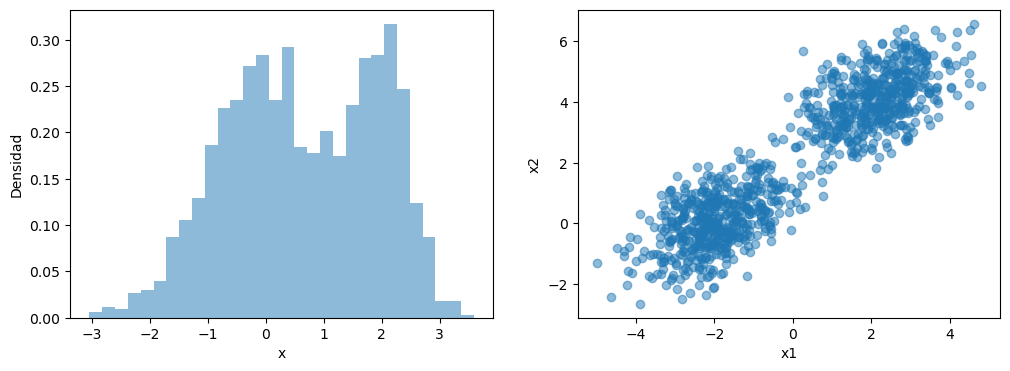

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x_1 = np.random.normal(0, 1, 1000)
x_2 = np.random.normal(2, 0.5, 500)
x = np.concatenate([x_1, x_2])


fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(x, bins=30, density=True, alpha=0.5)
axs[0].set_xlabel('x')
axs[0].set_ylabel('Densidad')

x_1 = np.random.multivariate_normal(mean=[-2, 0], cov=[[1, 0.5], [0.5, 1]], size=500)
x_2 = np.random.multivariate_normal(mean=[2, 4], cov=[[1, 0.5], [0.5, 1]], size=500)
x = np.concatenate([x_1, x_2])

axs[1].scatter(x[:, 0], x[:, 1], alpha=0.5)
axs[1].set_xlabel('x1')
axs[1].set_ylabel('x2')


plt.show()

### Aprendizaje Supervisado

Supongamos que tenemos un conjunto de observaciones de pares $(x_i, y_i)$, que denotamos como $T = \{(x_i, y_i)\}_{i=1}^N$. Asumimos que hay una relación entre las variables de entrada $X_1, X_2, \ldots, X_p$ y la variable de salida $Y$, que podemos expresar como una función desconocida $f$ más un término de error aleatorio $\epsilon$:

$$ Y = f(X) + \epsilon $$

$f$ representa la información *sistemática* que las variables $X$ proporcionan sobre la salida $Y$.

Las predicciones que obtenemos de esta relación se denotan como $\hat{Y}$. Si $Y$ toma valores en $\mathbb{R}$, entonces $\hat{Y}$ también tomará valores en $\mathbb{R}$. Si $Y$ es una variable categórica, entonces $\hat{Y}$ tomará valores en el conjunto de categorías $G$ asociado a $G$.


### Aprendizaje Supervisado

Supongamos que tenemos un conjunto de observaciones de pares $(x_i, y_i)$, que denotamos como $T = \{(x_i, y_i)\}_{i=1}^N$. Asumimos que hay una relación entre las variables de entrada $X_1, X_2, \ldots, X_p$ y la variable de salida $Y$, que podemos expresar como una función desconocida $f$ más un término de error aleatorio $\epsilon$:

$$ Y = f(X) + \epsilon $$

$f$ representa la información *sistemática* que las variables $X$ proporcionan sobre la salida $Y$.

Las predicciones que obtenemos de esta relación se denotan como $\hat{Y}$. Si $Y$ toma valores en $\mathbb{R}$, entonces $\hat{Y}$ también tomará valores en $\mathbb{R}$. Si $Y$ es una variable categórica, entonces $\hat{Y}$ tomará valores en el conjunto de categorías $G$ asociado a $G$.


**En jerga *Machine Learning*:**

Supongamos que $ Y = f(X) + \epsilon$ es una suposición razonable. En el Aprendizaje Supervisado, intentamos aprender $f$ a través de *ejemplos*, es decir, del conjunto de entrenamiento $T = \{(x_i, y_i)\}_{i=1}^N$. Estos pares de observaciones son utilizados por el *algoritmo de aprendizaje* (que suele ser un programa de computadora) para generar una función aproximada $\hat{f}$ que intenta replicar la relación entre $X$ e $y$. El algoritmo de aprendizaje tiene la capacidad de modificar la relación entre entradas y salidas a partir de las diferencias $y_i - \hat{f}(x_i)$ (errores). A este proceso se lo conoce como *aprendizaje por ejemplos*. Al finalizar este proceso, se espera que la salida generada por el algoritmo de aprendizaje sea lo suficientemente cercana a la salida real para ser útil en la práctica para cualquier conjunto de entradas que se encuentre.

### Inferencia vs predicción

#### **Predicción**

Atributos ($\textbf{X}$, inputs) fácilmente conseguibles, pero no así las etiquetas ($y$, outputs)
        
→ Usamos el modelo para obtener $\hat{y}$


**Ejemplo**
* $\textbf{X}$: variables fácilmente medibles en un análisis de sangre
* $y$: embarazo o no 

#### **Inferencia**
Nos interesa entender la relación entre $\textbf{X}$ e $y$, no necesariamente para hacer predicciones.

¿Cuáles predictores - elementos de $\textbf{X}$ - están asociados con $y$? ¿Cuál es esa relación?¿Es lineal?¿Es más compleja?

**Ejemplo**
* $\textbf{X}$: variables medidas en un análisis de sangre y otros estudios clínicos.
* $y$: diagnóstico de una enfermedad rara. 


## ¿Cómo podemos formalizar esto?

### Reglas de la probabilidad
**Caso discreto**

#### Regla de la suma

$$ p(X) = \sum_{Y} p(X,Y)$$

#### Regla del producto

$$ p(X,Y) = p(Y|X) p(X) $$

Que se pueden combinar para obtener el teorema de Bayes

$$ P(Y|X) = \frac{P(X|Y) P(Y)}{P(X)} $$

donde el denominador se puede calcular como

$$ P(X) = \sum_{Y} P(X|Y) P(Y) $$

### Reglas de la probabilidad
**Caso continuo**

$$ p(x \in (a,b)) = \int_{a}^{b} p(x) dx $$

$$ \int_{-\infty}^{\infty} p(x) dx = 1 $$


#### Regla de la suma

$$ p(x) = \int p(x,y) dy $$

#### Regla del producto

$$ p(x,y) = p(y|x) p(x) $$

### Enfoque bayesiano

* Algunos (muchos) eventos son difíciles de interpretar en términos de frecuencias.
* En estos casos, las nociones de incerteza son dífiles de interpretar en términos de frecuencias, sino que es más natural interpretarlas en términos de creencias.

#### Ejemplo - Ajuste de una curva

$$ p(\textbf{w}|\mathcal{D}) = \frac{p(\mathcal{D}|\textbf{w}) p(\textbf{w})}{p(\mathcal{D})} $$

donde $\mathcal{D}$ es el conjunto de datos observados y $\textbf{w}$ es el conjunto de parámetros del modelo. El denominador puede ser calculado como $p(\mathcal{D}) = \int p(\mathcal{D}|\textbf{w}) p(\textbf{w}) d\textbf{w}$.

* En el enfoque frecuentista, los parámetros son fijos y los datos son variables aleatorias. Las barras de error surgen de considerar la distribución de los datos.
* En el enfoque bayesiano, los datos son fijos y los parámetros son los que tienen una distribución. Las barras de error surgen de considerar la distribución de los parámetros.

### Aprendizaje Supervisado

Dado un conjunto de datos observados $\{(x_1,y_1),(x_2,y_2),\ldots,(x_N,y_N)\}$, el objetivo es aprender una relación entre $X$ e $Y$ que permita predecir $y$ ($\hat{y}$) dado un nuevo valor observado de $x$.

* En problemas de regresión, $Y$ toma valores continuos.
* En problemas de clasificación, $Y$ representará etiquetas de clases y, para ser consistentes con la notación, deberíamos llamarlo $G$.
    * $\hat{G}$ toma valores en el mismo conjunto de clases $\mathcal{G}$ asociado a $G$.


El problema de inferencia formulado de manera más general consiste en determinar la probabilidad conjunta $p(X,Y)$, ya que es la descripción probabilística más completa que podemos hacer.

¿Por qué? Si contamos con la probabilidad conjunta $p(X,Y)$, problema resuelto, ya que con el teorema de Bayes podemos hacer predicciones:

$$ p(Y = y|X = x) = \frac{p(X = x,Y = y)}{p(X = x)} $$

## Veamos algunos ejemplos y tratemos de bajar esto a algo más comprensible.

### Aprendizaje Supervisado

#### **Ejemplo 1**

Supongamos que queremos predecir si una persona aprobará una materia ($Y = 1$) o no ($Y = 0$) usando dos atributos:
* $X_1$: horas de estudio ($X_1 \in [0, 4]$)
* $X_2$: asistió o no a clases ($X_2 \in \{0, 1\}$)

En total, hay $5 \times 2 = 10$ combinaciones posibles de los atributos, junto con dos posibles valores para la variable de salida. En la siguiente tabla, están las probabilidades conjuntas de los atributos y la variable de salida ($P(X,Y) = P(X_1,X_2,Y)$).

<img src="Figuras/Tabla ejemplo p conjunta.png" alt="Figura 1" width="800" />


<!-- | $X_2$ $\backslash$ $X_1$ | 0                               | 1                               | 2                               | 3                               | 4                               |
|:------------------------:|:-------------------------------:|:-------------------------------:|:-------------------------------:|:-------------------------------:|:-------------------------------:|
|           0              | $P(0,0,0)=0.09$<br>$P(0,0,1)=0.01$ | $P(1,0,0)=0.07$<br>$P(1,0,1)=0.03$ | $P(2,0,0)=0.06$<br>$P(2,0,1)=0.04$ | $P(3,0,0)=0.05$<br>$P(3,0,1)=0.05$ | $P(4,0,0)=0.01$<br>$P(4,0,1)=0.09$ |
|           1              | $P(0,1,0)=0.08$<br>$P(0,1,1)=0.02$ | $P(1,1,0)=0.04$<br>$P(1,1,1)=0.06$ | $P(2,1,0)=0.03$<br>$P(2,1,1)=0.07$ | $P(3,1,0)=0.02$<br>$P(3,1,1)=0.08$ | $P(4,1,0)=0.005$<br>$P(4,1,1)=0.095$ | -->


### Aprendizaje Supervisado

#### **Ejemplo 1**

<img src="Figuras/Tabla ejemplo p conjunta.png" alt="Figura 1" width="800" />

A partir de esta tabla, podemos calcular las probabilidades condicionales de aprobar la materia ($Y = 1$) dado las horas de estudio ($X_1$) y si asistió a clases ($X_2$) como:

$$ P(Y = 1 | X_1 = x_1, X_2 = x_2) = \frac{P(X_1 = x_1, X_2 = x_2, Y = 1)}{P(X_1 = x_1, X_2 = x_2)} $$

y su complemento:

$$ P(Y = 0 | X_1 = x_1, X_2 = x_2) = \frac{P(X_1 = x_1, X_2 = x_2, Y = 0)}{P(X_1 = x_1, X_2 = x_2)} $$

En este caso, y por construcción para facilitar las cuentas, todas las combinaciones de los atributos - cada celda - son igualmente probables, $P(X_1 = x_1, X_2 = x_2) = \frac{1}{10}$.



### Aprendizaje Supervisado

#### **Ejemplo 1**

<img src="Figuras/Tabla ejemplo p conjunta.png" alt="Figura 1" width="800" />

Que, condicionada, da:

<img src="Figuras/Tabla ejemplo p condicional.png" alt="Figura 1" width="800" />

<!-- | $X_2$ $\backslash$ $X_1$ |  0                         |  1                         |  2                         |  3                         |  4                         |
|:------------------------:|:--------------------------:|:--------------------------:|:--------------------------:|:--------------------------:|:--------------------------:|
|           0              | $P(Y=0)=0.9$<br>$P(Y=1)=0.1$ | $P(Y=0)=0.7$<br>$P(Y=1)=0.3$ | $P(Y=0)=0.6$<br>$P(Y=1)=0.4$ | $P(Y=0)=0.5$<br>$P(Y=1)=0.5$ | $P(Y=0)=0.1$<br>$P(Y=1)=0.9$ |
|           1              | $P(Y=0)=0.8$<br>$P(Y=1)=0.2$ | $P(Y=0)=0.4$<br>$P(Y=1)=0.6$ | $P(Y=0)=0.3$<br>$P(Y=1)=0.7$ | $P(Y=0)=0.2$<br>$P(Y=1)=0.8$ | $P(Y=0)=0.05$<br>$P(Y=1)=0.95$ | -->


Con esta tabla, entonces, podemos calcular la probabilidad de que una persona apruebe la materia dado sus horas de estudio y si asistió a clases.


### Aprendizaje Supervisado

#### **Ejemplo 1**

<img src="Figuras/Tabla ejemplo p condicional.png" alt="Figura 1" width="800" />


Con esta tabla, entonces, podemos calcular la probabilidad de que una persona apruebe la materia dado sus horas de estudio y si asistió a clases.

**Importante**: en ningún momento estamos considerando cómo obtener la tabla original. Pero, una vez obtenida, es una descripción probabilística completa de la relación entre los atributos y la variable de salida.

¿Cuál les parece más cómoda para trabajar?¿Cuál es más fácil de *medir*?


### Aprendizaje Supervisado

#### **Ejemplo 2**

*Vamos al código*

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
X1_vals = np.arange(0, 5)       # 0,1,2,3,4
X2_vals = np.array([0, 1])      # 0,1
n_per_cell = 100                # Observaciones por celda

# Definimos p_{ij} = P(Y=1 | X1=i, X2=j)
# Cada fila i suma a 1, garantizando P(Y=1|X1=i)=0.5
p_table = {
    # X1: {X2: p(Y=1)}
    0: {0: 0.0, 1: 0.05},   # pura: siempre Y=0 si X2=0, siempre Y=1 si X2=1
    1: {0: 0.10, 1: 0.25},   # pura inversa
    2: {0: 0.20, 1: 0.45},   # mixta
    3: {0: 0.30, 1: 0.6},   # mixta
    4: {0: 0.40, 1: 0.95},   # mixta
}

# Generación de datos
rows = []
for i in X1_vals:
    for j in X2_vals:
        print(f"Generando datos para X1={i}, X2={j}")
        p1 = p_table[i][j]
        # Simulamos n_per_cell observaciones con probabilidad p1 de Y=1
        y_samples = np.random.binomial(1, p1, size=n_per_cell)
        for y in y_samples:
            rows.append({'X1': i, 'X2': j, 'Y': y})

df = pd.DataFrame(rows).sample(frac=1).reset_index(drop=True)
df.head(20)

Generando datos para X1=0, X2=0
Generando datos para X1=0, X2=1
Generando datos para X1=1, X2=0
Generando datos para X1=1, X2=1
Generando datos para X1=2, X2=0
Generando datos para X1=2, X2=1
Generando datos para X1=3, X2=0
Generando datos para X1=3, X2=1
Generando datos para X1=4, X2=0
Generando datos para X1=4, X2=1


,X1,X2,Y
0,0,0,0
1,2,1,0
2,4,0,0
3,2,1,1
4,2,0,0
5,0,1,0
6,3,0,1
7,1,0,0
8,3,0,0
9,0,1,0


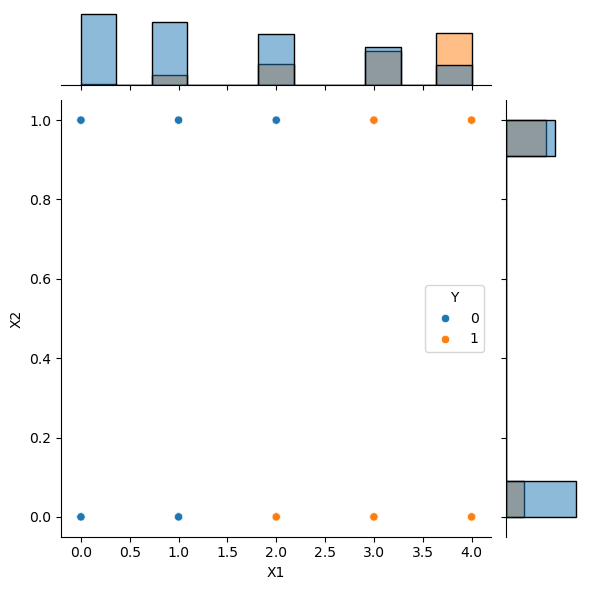

In [10]:
g = sns.JointGrid(data=df, x="X1", y="X2", hue="Y")
g.plot(sns.scatterplot, sns.histplot)

<Axes: xlabel='X1_jitter', ylabel='X2_jitter'>

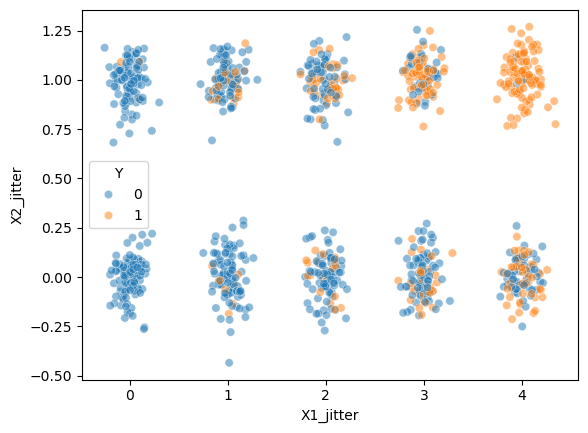

In [11]:
df['X1_jitter'] = df['X1'] + np.random.normal(0, 0.1, size=len(df))  # Añadir ruido a X1
df['X2_jitter'] = df['X2'] + np.random.normal(0, 0.1, size=len(df))  # Añadir ruido a X2


sns.scatterplot(data=df, x='X1_jitter', y='X2_jitter', hue='Y', alpha = 0.5)

In [15]:
p_1 = df.pivot_table(index='X1', columns='X2', values='Y', aggfunc='mean')
print("\nP(Y=1 | X1, X2):\n", p_1.T)


P(Y=1 | X1, X2):
 X1     0     1     2     3     4
X2                              
0   0.00  0.11  0.26  0.26  0.48
1   0.05  0.26  0.44  0.63  0.95


In [16]:
# Márgenes
condicional_X1 = df.groupby('X1')['Y'].mean()   
condicional_X2 = df.groupby('X2')['Y'].mean() 

# df.query('X1 == 4').Y.value_counts(normalize=False)

print("P(Y=1 | X1):\n", condicional_X1)
print("\nP(Y=1 | X2):\n", condicional_X2)

P(Y=1 | X1):
 X1
0    0.025
1    0.185
2    0.350
3    0.445
4    0.715
Name: Y, dtype: float64

P(Y=1 | X2):
 X2
0    0.222
1    0.466
Name: Y, dtype: float64


### Aprendizaje Supervisado

#### **Ejemplo 3**

Clasificación, analítico --> Lo dejamos para cuando veamos Análisis Discriminante.

### Aprendizaje Supervisado

#### **Ejemplo 4 - Regresión**

Supongamos:
* Dos atributos predictivos continuos $X_1, X_2$, normales, independientes entre sí o no.
* Un target continuo $Y$, que depende linealmente de los atributos, junto con ruido gaussiano.

Entonces, 

$$
\begin{aligned}
p(x_1, x_2, y) =\ & 
\frac{1}{2\pi |\Sigma_X|^{1/2}}
\exp\left(
-\frac{1}{2}
\left(
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}
- \boldsymbol{\mu}_X
\right)^\top
\Sigma_X^{-1}
\left(
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}
- \boldsymbol{\mu}_X
\right)
\right) \\
& \times
\frac{1}{\sqrt{2\pi}\, \sigma}
\exp\left(
-\frac{1}{2\sigma^2}
\left[ y - (\beta_0 + \beta_1 x_1 + \beta_2 x_2) \right]^2
\right)
\end{aligned}
$$

es una descripción completa del problema.

## ¿Problema resuelto? En todos los ejemplos, obtuvimos una distribución de probabilidad, no una *predicción*.

### Teoría de la decisión

$$ p(Y|X) = \frac{p(X,Y)}{p(X)} $$

Para hacer una predicción, necesitamos una *decisión* que nos diga qué valor $y$ predecir dado $x$.

La rama de la estadística que se ocupa de la toma de decisiones es la *teoría de la decisión*.

En particular, nos gustaría que esta decisión sea *óptima*, es decir, que minimice algún tipo de error o pérdida esperada.

### Teoría de la decisión *a la Bishop*

#### **Clasificación**

1. Para problemas de clasificación, podemos minimizar la probabilidad de error (que es equivalente a maximizar la probabilidad de acierto).

1. Necesitamos una regla que asigne cada vector de entrada $X = x$ a una de las clases en $\mathcal{G}$. Esa regla va a dividir el espacio de entrada en regiones de decisión, una para cada clase, donde cada punto en la región de decisión $R_k$ se asigna a la clase $K$-ésima. 

1. Las fronteras entre las regiones de decisión se llaman fronteras de decisión. Cabe destacar que cada región de decisión no tiene por qué ser contigua, sino que puede estar compuesta por varias regiones disjuntas.

### Teoría de la decisión *a la Bishop*

<img src="Figuras/Error de clasificación 2d.png" alt="Figura 1" width="400" />

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Parámetros de las dos clases
mu1, sigma1 = 0.0, 1.0
mu2, sigma2 = 2.0, 1.0
# Priori (iguales aquí)
pi1, pi2 = 0.5, 0.5

# Eje x
x = np.linspace(-4, 6, 2000)
# Densidades
p1 = pi1 * (1/(np.sqrt(2*np.pi)*sigma1)) * np.exp(-0.5*((x-mu1)/sigma1)**2)
p2 = pi2 * (1/(np.sqrt(2*np.pi)*sigma2)) * np.exp(-0.5*((x-mu2)/sigma2)**2)

def plot_decision(threshold):
    plt.figure(figsize=(8, 4))
    plt.plot(x, p1, label=r'$p(x\,|\,C_1)$', color='C0')
    plt.plot(x, p2, label=r'$p(x\,|\,C_2)$', color='C1')
    
    # Regiones de decisión
    # R1: x < threshold → predicción C1
    # R2: x >= threshold → predicción C2
    plt.fill_between(x, 0, p1, where=(x < threshold), color='C0', alpha=0.3)
    plt.fill_between(x, 0, p2, where=(x >= threshold), color='C1', alpha=0.3)
    
    # Zonas de error
    # - puntos de C1 en R2 (x>=threshold): área bajo p1 para x>=threshold
    # - puntos de C2 en R1 (x<threshold): área bajo p2 para x<threshold
    err1 = np.trapezoid(p1[x >= threshold], x[x >= threshold])
    err2 = np.trapezoid(p2[x < threshold],  x[x < threshold])
    
    # Sombreo de errores
    plt.fill_between(x, 0, p1, where=(x >= threshold), color='red',   alpha=0.5, label='Error C1→C2')
    plt.fill_between(x, 0, p2, where=(x < threshold),  color='orange', alpha=0.5, label='Error C2→C1')
    
    # Línea vertical del umbral
    plt.axvline(threshold, color='k', linestyle='--')
    plt.text(threshold, max(p1.max(), p2.max())*0.9,
             fr'$\hat x={threshold:.2f}$', ha='right')
    
    plt.title(f'Error total = {err1+err2:.3f}  (C1→C2: {err1:.3f},  C2→C1: {err2:.3f})')
    plt.xlabel('$x$')
    plt.ylabel('Densidad conjunta $p(x,C_k)$')
    plt.legend(loc='upper left')
    plt.ylim(0, max(p1.max(), p2.max())*1.1)
    plt.show()

# Deslizador interactivo
interact(plot_decision,
         threshold=FloatSlider(min=-2, max=5, step=0.05, value=1.0,
                               description='Umbral')); 


interactive(children=(FloatSlider(value=1.0, description='Umbral', max=5.0, min=-2.0, step=0.05), Output()), _…

### Teoría de la decisión *a la Bishop*

Supongamos que solamente hay dos clases, $C_1$ y $C_2$, cada una con una región de decisión $\mathcal{R}_1$ y $\mathcal{R}_2$, respectivamente. Entonces, la probabilidad de cometer un error es:

$$p(error) = p(x \in \mathcal{R}_1, y = C_2) + p(x \in \mathcal{R}_2, y = C_1)$$

$$p(error) = \int_{\mathcal{R}_1} p(x,C_2) dx + \int_{\mathcal{R}_2} p(x,C_1) dx$$

Considerando que $p(x,C_k) = p(C_k|x) p(x)$, podemos reescribir la expresión anterior como:

$$p(error) = \int_{\mathcal{R}_1} p(C_2|x) p(x) dx + \int_{\mathcal{R}_2} p(C_1|x) p(x) dx$$

Como $p(x)$ es común a ambos términos, podemos reescribir este resultado diciendo que la probabilidad mínima de cometer un error se obtiene si cada valor de $x$ se asigna a la clase para la cual la probabilidad posterior $p(C_k|x)$ es mayor, que es la famosa **regla de Bayes**:

$$\hat{G} = \arg\max_{C_k} p(C_k|x)$$

### Teoría de la decisión - Clasificación

Otra forma de verlo, con una notación más cargada pero un poco más general.

* La variable de salida de una variable categórica $G$ que toma valores en $\mathcal{G}$.
* El estimador es $\hat{G}(X)$, que también toma valores en $\mathcal{G}$.
* La función de pérdida es una matriz $\textbf{L}$ de tamaño $K \times K$, que es cero en la diagonal y no negativa en el resto. Es decir, $L(k, \ell)$ es el costo de clasificar un elemento de la clase $\mathcal{G}_k$ como $\mathcal{G}_\ell$.
* En general, se usa la zero-one loss, que es cero si $k = \ell$ y uno en caso contrario.

Entonces, el error de predicción esperado es:

$$ EPE = E[L(G,\hat{G}(X))]$$

### Teoría de la decisión - Clasificación

El error de predicción esperado es:

$$ EPE = E[L(G,\hat{G}(X))]$$

¿Sobre qué está tomada la esperanza? Sobre la distribución conjunta de $X$ y $G$, es decir, $p(G,X)$. Entonces, podemos escribirlo como:

$$ EPE = \int_{X}\sum_{k=1}^{K} L(\mathcal{G}_k,\hat{G}(X)) p(\mathcal{G}_k | X) p(X) dX  $$

que lo van a encontrar de manera parecida a 

$$ EPE = E_{X}[\sum_{k=1}^{K} L(\mathcal{G}_k,\hat{G}(X)) p(\mathcal{G}_k | X)]  $$

¿Se parece a lo que vimos antes (Bishop)?


### Teoría de la decisión - Clasificación

$$ EPE = E_{X}[\sum_{k=1}^{K} L(\mathcal{G}_k,\hat{G}(X)) p(\mathcal{G}_k | X)]  $$

Notar que el operador $E_X[\cdot]$ es un promedio ponderado por $p(X)$ para todos los posibles valores de $X$.

Para minimizar la EPE, **basta con minimizarla puntualmente (es decir, para cada punto $X$ fijo).**

**¿Por qué se puede minimizar punto a punto?**

El error promedio esperado es una **suma (o integral) sobre todos los posibles valores de $X$** de un término que depende solo de $X$

$$ EPE = \int_{X} \Biggr[ \sum_{k=1}^{K} L(\mathcal{G}_k,\hat{G}(X)) p(\mathcal{G}_k | X) \Biggr] p(X) dX  $$

Notar que el término dentro del corchete el **error esperado local** para ese valor de $X$ y **solo depende de la decisión que tomemos para ese valor de $X$**.

Así, el EPE es la suma (integral) de términos independientes, uno para cada $X$, y **el clasificador $\hat{G}(X)$ puede ser elegido de manera independente para cada valor de $X$** (las decisiones de un valor de $X$ no deben afectar otro valor de $X$).

Entonces, **para minimizar el EPE global, alcanza con minimizar el término dentro del corchete para cada  valor $X$ por separado (minimización local)**.

### Teoría de la decisión - Clasificación

$$ EPE = E_{X}[\sum_{k=1}^{K} L(\mathcal{G}_k,\hat{G}(X)) p(\mathcal{G}_k | X)]  $$

Para minimizar la EPE, basta con minimizarla puntualmente (es decir, para cada punto $x$ fijo), lo que nos lleva a la regla de Bayes:

$$ \hat{G}(x) = \arg\min_{g \in \mathcal{G} } (\sum_{k=1}^{K} L(\mathcal{G}_k,g) p(\mathcal{G}_k | X = x)) $$

que es general para cualquier $L$.

En el caso particular de la zero-one loss, la regla de Bayes se reduce a:

$$ \hat{G}(x) = \arg\min_{g \in \mathcal{G} } [1 - p(g | X = x)] $$

o, de manera equivalente

$$ \hat{G}(x) = \mathcal{G}_k \text{ si } p(\mathcal{G}_k | X = x) = \max_{g \in \mathcal{G}} p(g | X = x) $$

Que se interpreta como que la clase predicha es aquella que tiene la mayor probabilidad condicional sobre la distribución - discreta - $P(G|X)$.

### Aprendizaje Supervisado - Clasificación

$$ p(G|X) = \frac{p(X,G)}{p(X)} $$

Ya sabemos cómo usar $p(X,G)$ para tomas decisiones sobre $G$ dado $X$. Sin embargo, tenemos un problema aún más complicado:

Determinar $p(X,G)$ suele ser muy difícil.

¿Por qué? 

Porque $X$ suele ser un vector de alta dimensión, y estimar distribuciones en alta dimensión es muy difícil.

¿La solución? Modelar.

### Aprendizaje Supervisado - Clasificación

#### Inferencia y decisión

La resolución de un problema de clasificación requiere de dos instancias: la *inferencia* y la *decisión*.
* En la *inferencia*, usamos datos de entrenamiento para estimar la distribución conjunta $p(X,G)$ o la distribución condicional $p(G|X)$.
* En la *decisión*, usamos la distribución estimada para hacer predicciones sobre la clase $G$ dado un nuevo valor de $X$, ya sea usando la regla de Bayes o no.

Podemos identificar tres aproximaciones distintas para un problema de clasificación, ordenados de manera decreciente según su complejidad.

### Aprendizaje Supervisado - Clasificación

1. **Modelos generativos**: 
    1. Modelar la distribución conjunta $p(X,G)$. 
    1. Luego, calcular la distribución condicional $p(G|X)$ normalizando. 
    1. Finalmente, usar teoría de la decisión para hacer predicciones.

    Se llaman generativos porque, al modelar la distribución conjunta, es posible generar datos sintéticos en el espacio de entrada.

1. **Modelos discrimativos**:
    1. Modelar directamente la distribución condicional $p(G|X)$.
    1. Usar teoría de la decisión para hacer predicciones
    
1. **Función discriminante**: directamente aprender una función de decisión que mapea $X$ a $G$. No modelan ninguna distribución de probabilidad. De esta forma, combinan la inferencia y la decisión en un solo paso.

### Teoría de la decisión - Regresión

De manera parecida a como hicimos en clasificación, debemos decidir qué valor predecir de $Y$ en un problema de regresión.

* $X \in \mathbb{R}^p$ es un vector de atributos predictivos.
* $Y \in \mathbb{R}$ es un valor continuo a predecir.
* $P(X,Y)$ es su distribución conjunta.

Buscamos una función $f(X)$ que prediga $Y$ dado $X$. La función de pérdida típica es la pérdida cuadrática, $L(Y,f(X)) = (Y - f(X))^2$. Entonces:

$$ EPE(f) = E[L(Y,f(X))] = E[(Y - f(X))^2] $$

Que, de manera muy parecida, podemos reescribir como

$$ EPE(f) = \int (y - f(x))^2 p(x,y) dy dx  $$

Condicionando, 

$$ EPE(f) = \int (y - f(x))^2 p(y|x) p(x) dy dx $$

$$ EPE(f) = E_{X}E_{Y|X} ([Y - f(X)]^2|X) $$

### Teoría de la decisión - Regresión

$$ EPE(f) = \int (y - f(x))^2 p(y|x) p(x) dy dx $$

$$ EPE(f) = E_{X}E_{Y|X} ([Y - f(X)]^2|X) $$

Nuevamente, basta con minimizar punto a punto, por lo que buscamos un $c$ tal que:

$$ f(x) = \arg\min_{c \in \mathbb{R}} E_{Y|X} ([Y - c]^2|X) $$

Cuya solución es

$$f(x) = E(Y|X = x) $$

que se conoce como la función de regresión.

¿Qué quiere decir? La mejor predicción de $Y$ en un punto $X = x$ es la media condicional (cuando es medido por el error cuadrático).

### Aprendizaje Supervisado - Regresión

Así como en clasificación, hay tres formas de abordar un problema de regresión, ordenadas de manera decreciente según su complejidad.

1. Modelar la distribución conjunta $p(X,Y)$. Luego, calculan la distribución condicional $p(Y|X)$ normalizando. Finalmente, obtener su promedio condicional, que es la predicción óptima bajo el error cuadrático medio.

1. Modelar la distribución condicional $p(Y|X)$. Luego, obtener su promedio condicional, que es la predicción óptima bajo el error cuadrático medio.

1. Directamente modelar $E[Y|X]$, que es la predicción óptima bajo el error cuadrático medio.


### Ejercicios

**Ejercicio:** dados los siguientes problemas, elegir un conjunto de atributos que consideres que tengan poder predictivo.

1. Predecir el tiempo de viaje en colectivo de un punto A a un punto B.
1. Predecir el rinde de un cultivo.
1. Decidir si una operación con una tarjeta de crédito es fraudulenta o no.
1. Calcular el consumo de carne en una familia tipo.
1. Decidir si un texto fue generado por un gran modelo de lenguaje (LLM) o escrito por un humano.

**Ejercicio:** decidir cuáles de los siguientes problemas conviene abordarlos con aprendizaje automático y cuáles no.

1. Decidir si un número es primo.
1. Obtener la edad de una persona a partir de su comportamiento en redes sociales.
1. Calcular la probabilidad de rotura de un caño en un pozo petrolífero.
1. Calcular la ruta más corta entre dos puntos del mapa de una ciudad.
1. Decidir el tamaño óptimo para una lata de bebidas dados ciertas restricciones de las dimensiones.


¿Qué otros enfoques se te ocurren?
